In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib notebook
import random as rand
from runtumble import Cell, Wall, RTP

In [3]:
c = Cell(default_walls=False)
p = RTP()
c.add_particle(p)
w1 = Wall(0,0,0,c.cell_size[1]/2)
w2 = Wall(c.cell_size[0], 0, c.cell_size[0], c.cell_size[1]/2)
w3 = Wall(c.cell_size[0], c.cell_size[1]/2, c.cell_size[0]/2, c.cell_size[1]/2)
w4 = Wall(c.cell_size[0], c.cell_size[1]/2, c.cell_size[0], 3*c.cell_size[1]/4)
for w in [w1, w2, w3, w4]:
    c.add_wall(w)
# print(f"({p.x},{p.y}), {p.angle}")

In [4]:
c.add_wall(Wall(10,5,10,10))
c.add_wall(Wall(0,5,10,0))

In [5]:
c.set_field(0.1)
c.set_pbc(False)
c.set_velocity(0.5)
c.set_decay_rate(0.5)
c.set_RTP_radius(0.1)
print(f"field: {p.FIELD}\nperiodic bc: {p._periodic}\nvelocity: {p.VELOCITY}\ndecay rate: {p.RATE}\nradius: {p.RADIUS}")

field: 0.1
periodic bc: False
velocity: 0.5
decay rate: 0.5
radius: 0.1


In [10]:
x0, y0 = rand.random() * c.cell_size[0], rand.random() * c.cell_size[1]
print(f"initial pos: {x0}, {y0}")

c.left_flux = 0
c.right_flux = 0
p.set_r(x0, y0)
p.tumble()

N = 20000
path = []
for i in range(N):
    path.append(p.get_r())
    p.run(0.1)
    print(i+1, end='\r')

path = np.array(path).T

initial pos: 0.5377513459421335, 4.969913246186484


<IPython.core.display.Javascript object>


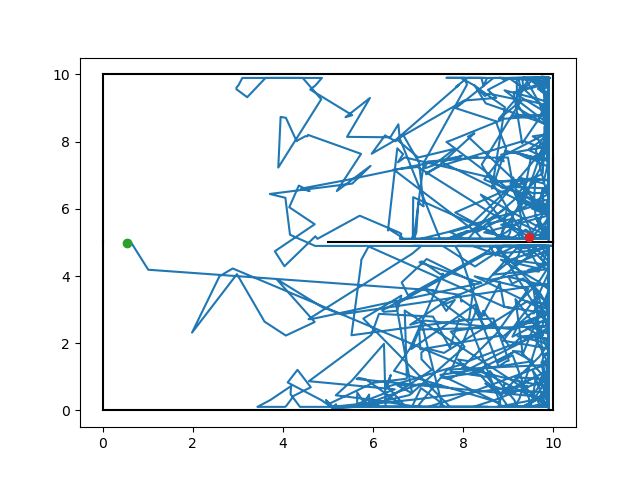

In [11]:
fig, ax = plt.subplots(1,1)

plt.plot(path[0], path[1])
plt.scatter(path[0][0], path[1][0], color='C2', zorder=5)
plt.scatter(path[0][-1], path[1][-1], color='C3', zorder = 3)
for wall in c.get_walls():
    wall.draw(ax)

# plt.savefig('20000_steps.png', dpi=300)

In [22]:
print(f"left flux: {c.left_flux}\nright flux: {c.right_flux}")

left flux: 2
right flux: 6


In [12]:
p.set_r(2.5, 7.5)
p.angle = np.pi/2
p.runtime = 5
p.moving_angle = p.free_moving_angle()
p.walls_on_path

In [6]:
def simulation(n):
    x0, y0 = rand.random() * c.cell_size[0], rand.random() * c.cell_size[1]
#     print(f"initial pos: {x0}, {y0}")

    c.left_flux = 0
    c.right_flux = 0
    p.set_r(x0, y0)
    p.tumble()

    path = []
    for i in range(n):
        path.append(p.get_r())
        p.run(0.1)
#         print(i, end='\r')
    return np.array(path).T

In [7]:
import cProfile
cProfile.run('simulation(50000)')

         7700474 function calls in 54.431 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.245    0.245   54.407   54.407 <ipython-input-6-5ae9cb16f3bb>:1(simulation)
        1    0.024    0.024   54.431   54.431 <string>:1(<module>)
     2561    0.008    0.000    0.015    0.000 random.py:437(expovariate)
   108657    1.725    0.000    1.725    0.000 runtumble.py:12(norm)
   607019   13.894    0.000   13.894    0.000 runtumble.py:15(cross)
   132108    1.026    0.000    1.026    0.000 runtumble.py:18(dot)
        1    0.000    0.000    0.000    0.000 runtumble.py:196(left_flux)
        1    0.000    0.000    0.000    0.000 runtumble.py:205(right_flux)
    37009    0.020    0.000    0.020    0.000 runtumble.py:267(get_walls)
   467453    0.213    0.000    0.213    0.000 runtumble.py:281(x)
    84100    0.137    0.000    0.137    0.000 runtumble.py:286(x)
   587022    0.266    0.000    0.266    0.000 runtumble.p